# Credit Card Fraud Detection — ML Analysis Report

---
## 1. Setup <a id='setup'></a>

**1.1 Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc
)


**1.2 Display Configurations**

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

**1.3 Load Data**

In [3]:
df_credits = pd.read_csv(r'/run/media/hasan/Projects/ML/02.Credit Card Fraud Detection/Data/creditcard.csv')
print(f"✅ Dataset loaded: {df_credits.shape[0]:,} rows | {df_credits.shape[1]} columns.")

✅ Dataset loaded: 284,807 rows | 31 columns.


---
## 2. Exploratory Data Analysis (EDA) & Data Cleaning <a id='eda'></a>

**2.1 Dataset Overview**

In [4]:
df_credits.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [5]:
print(f"{'#':<3} | {'Column Name':<25} | {'Data Type'}")
print("-" * 45)

for i, (col_name, col_type) in enumerate(df_credits.dtypes.items()):
    print(f"{i+1:<3} | {col_name:<25} | {str(col_type)}")

#   | Column Name               | Data Type
---------------------------------------------
1   | Time                      | float64
2   | V1                        | float64
3   | V2                        | float64
4   | V3                        | float64
5   | V4                        | float64
6   | V5                        | float64
7   | V6                        | float64
8   | V7                        | float64
9   | V8                        | float64
10  | V9                        | float64
11  | V10                       | float64
12  | V11                       | float64
13  | V12                       | float64
14  | V13                       | float64
15  | V14                       | float64
16  | V15                       | float64
17  | V16                       | float64
18  | V17                       | float64
19  | V18                       | float64
20  | V19                       | float64
21  | V20                       | float64
22  | V21                   

**2.2 Data Quality Check**

In [6]:
missing_cols = df_credits.columns[df_credits.isnull().any()].tolist()
duplicates   = df_credits.duplicated().sum()

print(f"Columns with missing values : {missing_cols if missing_cols else 'None'}")
print(f"Duplicate rows              : {duplicates:,}")

Columns with missing values : None
Duplicate rows              : 1,081


In [7]:
# Preview a sample of duplicated rows
duplicates_df = df_credits[df_credits.duplicated(keep=False)]
display(duplicates_df.sort_values(by=['Time', 'Amount']).head(10))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.000,-0.535,0.865,1.351,0.148,0.434,0.087,0.693,0.180,-0.286,-0.482,0.872,0.853,-0.572,0.102,-1.520,-0.286,-0.310,-0.404,-0.824,-0.283,0.050,0.207,-0.187,0.001,0.098,-0.553,-0.078,0.025,1.770,0
35,26.000,-0.535,0.865,1.351,0.148,0.434,0.087,0.693,0.180,-0.286,-0.482,0.872,0.853,-0.572,0.102,-1.520,-0.286,-0.310,-0.404,-0.824,-0.283,0.050,0.207,-0.187,0.001,0.098,-0.553,-0.078,0.025,1.770,0
32,26.000,-0.530,0.874,1.347,0.145,0.414,0.100,0.711,0.176,-0.287,-0.485,0.872,0.852,-0.572,0.101,-1.520,-0.284,-0.311,-0.404,-0.823,-0.290,0.047,0.208,-0.186,0.001,0.099,-0.553,-0.073,0.023,6.140,0
33,26.000,-0.530,0.874,1.347,0.145,0.414,0.100,0.711,0.176,-0.287,-0.485,0.872,0.852,-0.572,0.101,-1.520,-0.284,-0.311,-0.404,-0.823,-0.290,0.047,0.208,-0.186,0.001,0.099,-0.553,-0.073,0.023,6.140,0
112,74.000,1.038,0.127,0.184,1.110,0.442,0.945,-0.037,0.351,0.119,-0.243,0.578,0.675,-0.534,0.447,1.123,-1.768,1.241,-2.449,-1.747,-0.336,0.103,0.605,0.023,-0.626,0.479,-0.167,0.081,0.001,1.180,0
113,74.000,1.038,0.127,0.184,1.110,0.442,0.945,-0.037,0.351,0.119,-0.243,0.578,0.675,-0.534,0.447,1.123,-1.768,1.241,-2.449,-1.747,-0.336,0.103,0.605,0.023,-0.626,0.479,-0.167,0.081,0.001,1.180,0
114,74.000,1.038,0.127,0.184,1.110,0.442,0.945,-0.037,0.351,0.119,-0.243,0.578,0.675,-0.534,0.447,1.123,-1.768,1.241,-2.449,-1.747,-0.336,0.103,0.605,0.023,-0.626,0.479,-0.167,0.081,0.001,1.180,0
115,74.000,1.038,0.127,0.184,1.110,0.442,0.945,-0.037,0.351,0.119,-0.243,0.578,0.675,-0.534,0.447,1.123,-1.768,1.241,-2.449,-1.747,-0.336,0.103,0.605,0.023,-0.626,0.479,-0.167,0.081,0.001,1.180,0
220,145.000,-2.420,1.948,0.554,0.983,-0.282,2.409,-1.402,-0.188,0.676,0.158,-1.225,1.315,0.304,-0.290,-2.015,-0.773,0.697,0.018,2.177,-0.276,1.214,-1.239,0.007,-1.724,0.240,-0.314,-0.188,0.120,6.000,0
221,145.000,-2.420,1.948,0.554,0.983,-0.282,2.409,-1.402,-0.188,0.676,0.158,-1.225,1.315,0.304,-0.290,-2.015,-0.773,0.697,0.018,2.177,-0.276,1.214,-1.239,0.007,-1.724,0.240,-0.314,-0.188,0.120,6.000,0


**2.3 Data Cleaning**

In [8]:
def clean_duplicate_transactions(df: pd.DataFrame) -> pd.DataFrame:

    print("--- Data Cleaning Process Started ---")

    total_dupes = df.duplicated().sum()
    print(f"[!] Exact identical rows found: {total_dupes:,}")
    df_cleaned = df.drop_duplicates(keep='first').reset_index(drop=True)

    v_features = [f'V{i}' for i in range(1, 29)]
    feature_dupes = df_cleaned.duplicated(subset=v_features).sum()
    print(f"[!] Transactions with identical V1-V28 features: {feature_dupes:,}")
    df_cleaned = df_cleaned.drop_duplicates(subset=v_features, keep='first').reset_index(drop=True)

    print("\n--- Final Class Distribution After Deep Cleaning ---")
    dist      = df_cleaned['Class'].value_counts()
    dist_perc = df_cleaned['Class'].value_counts(normalize=True) * 100

    for cls, count in dist.items():
        label = "Fraud" if cls == 1 else "Normal"
        print(f"Class {cls} ({label}): {count:<7,} | {dist_perc[cls]:.3f}% of dataset")

    print(f"\nFinal Dataset Shape: {df_cleaned.shape}")
    print("--- Cleaning Complete ---")

    return df_cleaned


df_credits = clean_duplicate_transactions(df_credits)

--- Data Cleaning Process Started ---
[!] Exact identical rows found: 1,081
[!] Transactions with identical V1-V28 features: 8,063

--- Final Class Distribution After Deep Cleaning ---
Class 0 (Normal): 275,190 | 99.828% of dataset
Class 1 (Fraud): 473     | 0.172% of dataset

Final Dataset Shape: (275663, 31)
--- Cleaning Complete ---


**2.4 Class Imbalance Analysis**

In [9]:
counts      = df_credits['Class'].value_counts()
percentages = df_credits['Class'].value_counts(normalize=True) * 100

print(f"{'Class':<10} | {'Count':<10} | {'Percentage':<12}")
print("-" * 35)

for cls, count in counts.items():
    label = "Normal (0)" if cls == 0 else "Fraud  (1)"
    print(f"{label:<10} | {count:<10,} | {percentages[cls]:.3f}%")

imbalance_ratio = counts[0] / counts[1]
print("-" * 35)
print(f"Imbalance Ratio: 1 Fraud for every {imbalance_ratio:.0f} Normal transactions.")

Class      | Count      | Percentage  
-----------------------------------
Normal (0) | 275,190    | 99.828%
Fraud  (1) | 473        | 0.172%
-----------------------------------
Imbalance Ratio: 1 Fraud for every 582 Normal transactions.


**2.5 Data Visualizations**

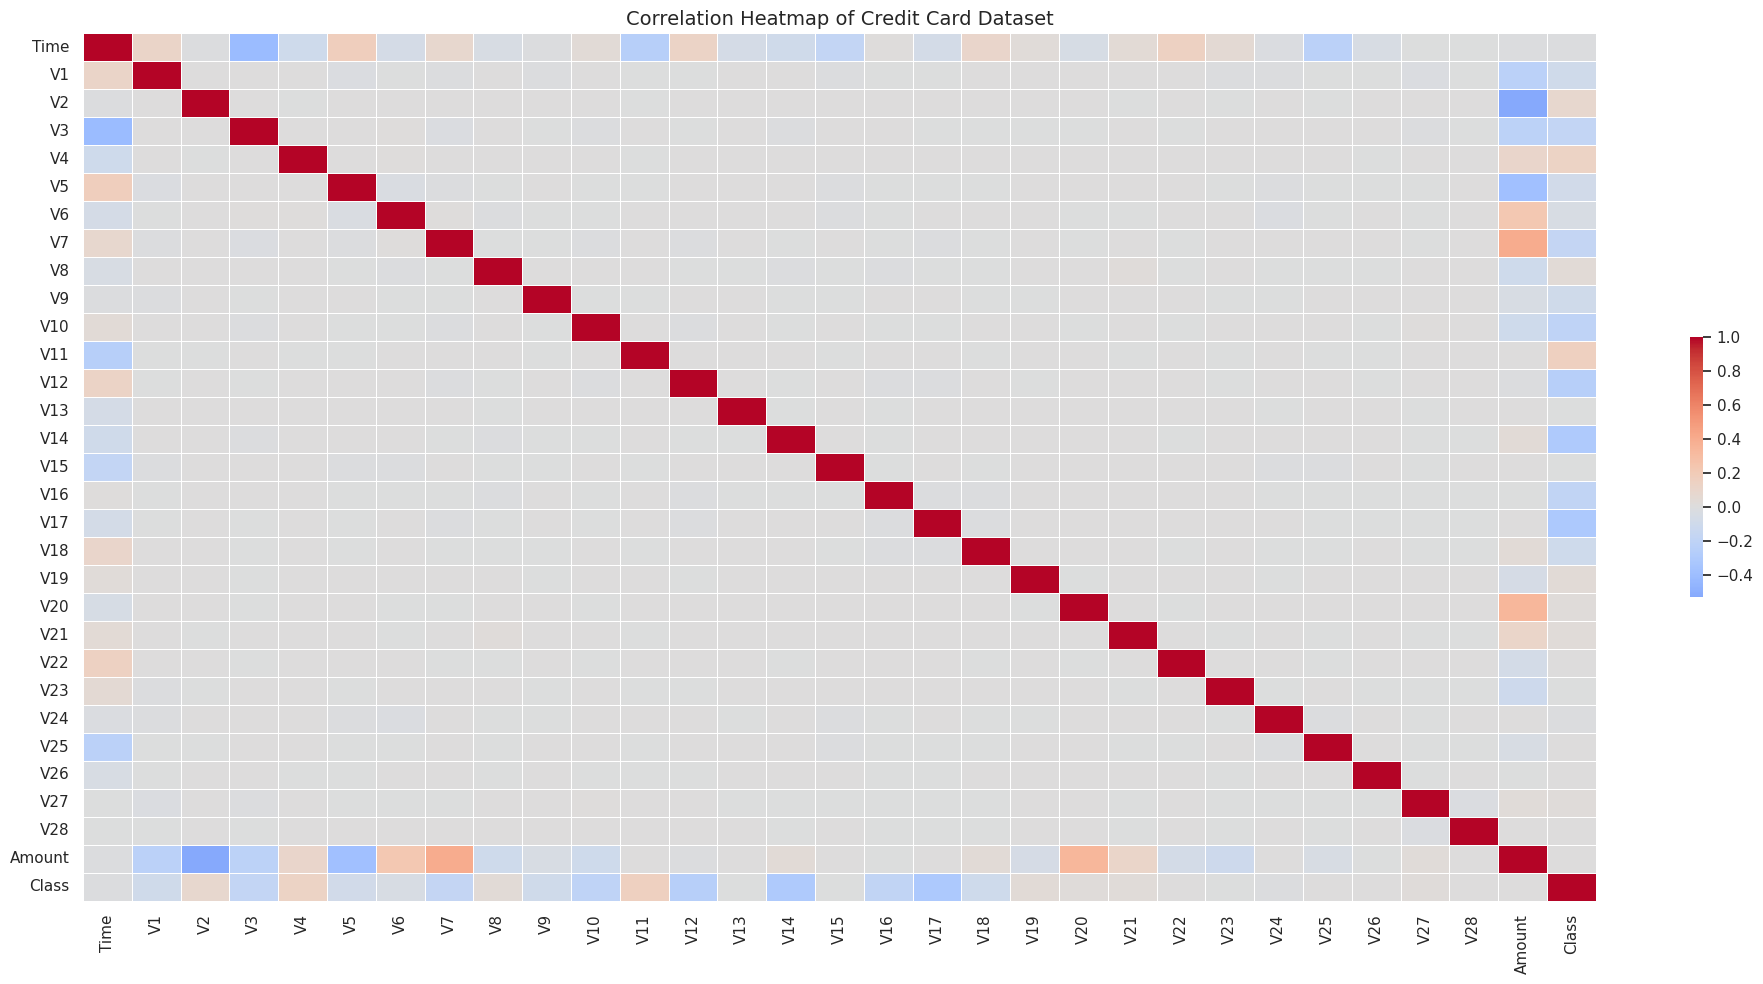

In [10]:
# Correlation Heatmap
df_corr = df_credits.corr(numeric_only=True)

plt.figure(figsize=(20, 10))
sns.heatmap(
    df_corr,
    cmap='coolwarm',
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.3}
)
plt.title("Correlation Heatmap of Credit Card Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Top/Bottom Features Correlated with Target
corr_target = df_credits.corr(numeric_only=True)['Class'].sort_values(ascending=False)

print("Correlation of features with the target variable (Class):")
print("\nTop 5 (positive):")
display(corr_target.head(5))

print("\nBottom 5 (negative):")
display(corr_target.tail(5))

Correlation of features with the target variable (Class):

Top 5 (positive):


Class   1.000
V11     0.151
V4      0.130
V2      0.085
V19     0.034
Name: Class, dtype: float64


Bottom 5 (negative):


V16   -0.188
V10   -0.208
V12   -0.253
V14   -0.298
V17   -0.317
Name: Class, dtype: float64

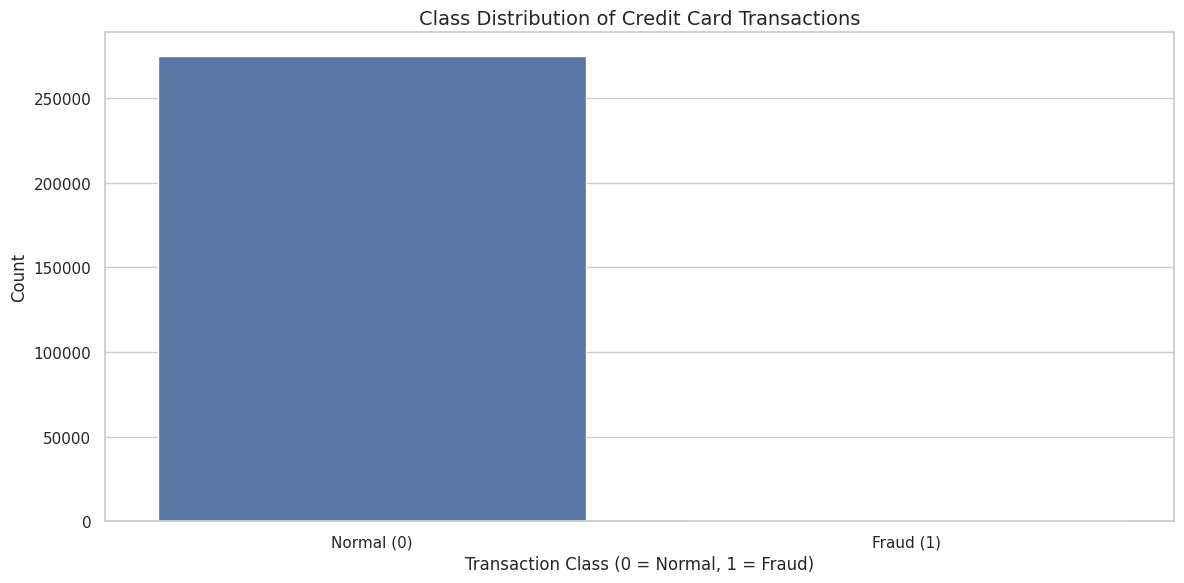

In [12]:
# Class Distribution Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(x='Class', data=df_credits)
plt.title("Class Distribution of Credit Card Transactions", fontsize=14)
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

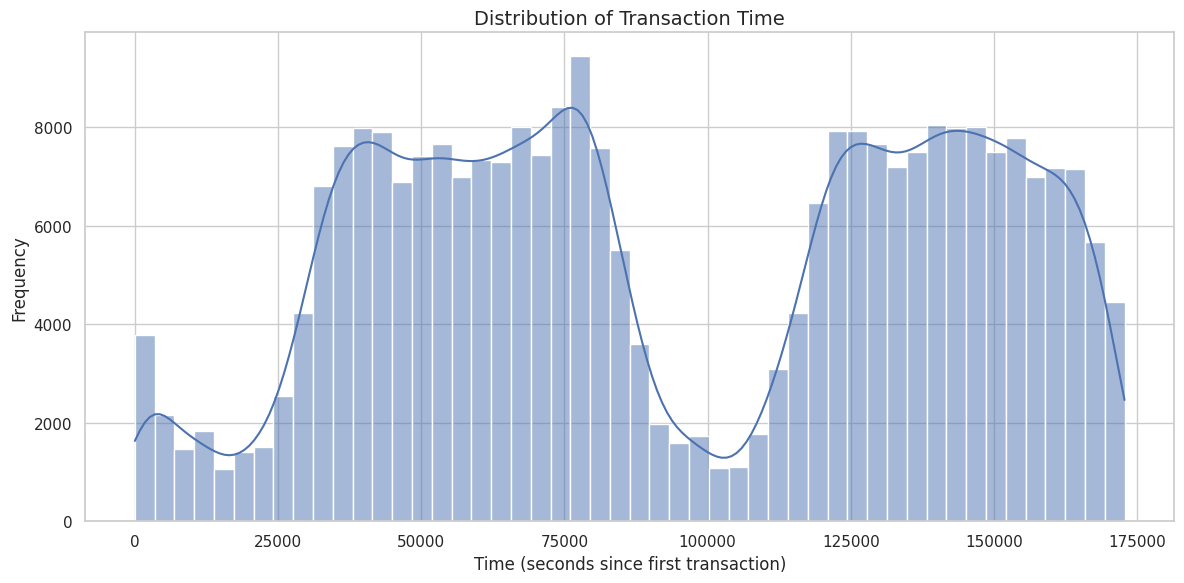

In [13]:
# Distribution of Transaction Time
plt.figure(figsize=(12, 6))
sns.histplot(df_credits['Time'], bins=50, kde=True)
plt.title("Distribution of Transaction Time", fontsize=14)
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

  Fraud Transactions — Amount Statistics
  Count   : 473
  Mean    : $123.87
  Median  : $9.82
  Std     : $260.21
  Min     : $0.00
  Max     : $2125.87
  >$1000  : 9 transactions

  Normal Transactions — Amount Statistics
  Count   : 275,190
  Mean    : $90.52
  Median  : $23.75


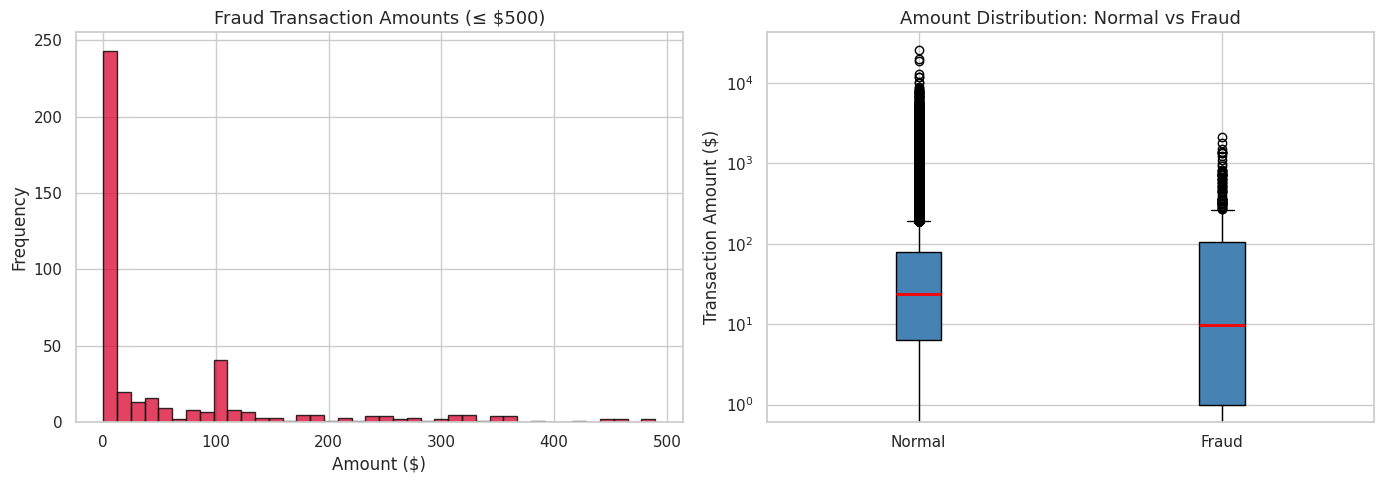

In [14]:
# 2.6 Fraud Amount Statistics
fraud_df   = df_credits[df_credits['Class'] == 1]['Amount']
normal_df  = df_credits[df_credits['Class'] == 0]['Amount']

print("=" * 45)
print("  Fraud Transactions — Amount Statistics")
print("=" * 45)
print(f"  Count   : {len(fraud_df):,}")
print(f"  Mean    : ${fraud_df.mean():.2f}")
print(f"  Median  : ${fraud_df.median():.2f}")
print(f"  Std     : ${fraud_df.std():.2f}")
print(f"  Min     : ${fraud_df.min():.2f}")
print(f"  Max     : ${fraud_df.max():.2f}")
print(f"  >$1000  : {(fraud_df > 1000).sum():,} transactions\n")

print("=" * 45)
print("  Normal Transactions — Amount Statistics")
print("=" * 45)
print(f"  Count   : {len(normal_df):,}")
print(f"  Mean    : ${normal_df.mean():.2f}")
print(f"  Median  : ${normal_df.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fraud_df[fraud_df <= 500], bins=40, color='crimson', edgecolor='black', alpha=0.8)
axes[0].set_title("Fraud Transaction Amounts (≤ $500)", fontsize=13)
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot([normal_df, fraud_df], tick_labels=['Normal', 'Fraud'], patch_artist=True,
                boxprops=dict(facecolor='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Amount Distribution: Normal vs Fraud", fontsize=13)
axes[1].set_ylabel("Transaction Amount ($)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


---
## 3. Data Preprocessing <a id='preprocessing'></a>

**3.1 Feature Engineering**

In [15]:
df_credits['Amount_log'] = np.log1p(df_credits['Amount'])
df_credits['Hour'] = (df_credits['Time'] // 3600 % 24).astype(int)

X = df_credits.drop(columns=['Class', 'Amount', 'Time'])
y = df_credits['Class']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Class distribution   : {y.value_counts().to_dict()}")
print(f"New features added   : Amount_log, Hour")

Feature matrix shape : (275663, 30)
Target vector shape  : (275663,)
Class distribution   : {0: 275190, 1: 473}
New features added   : Amount_log, Hour


**3.Time Feature Engineering**

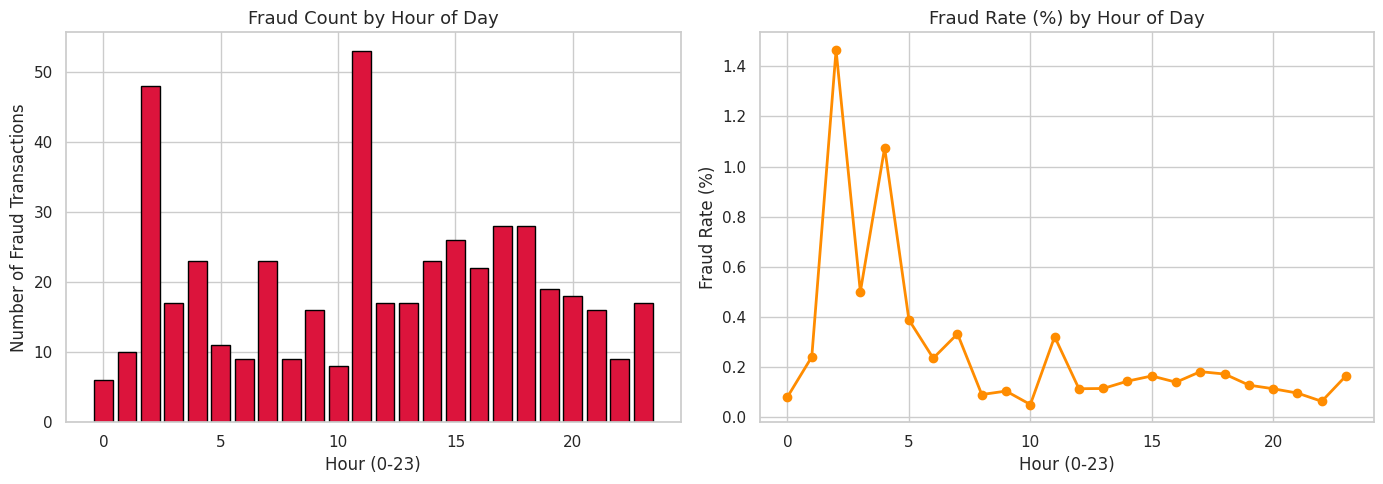

In [16]:
fraud_by_hour = df_credits.groupby('Hour')['Class'].agg(['sum', 'count'])
fraud_by_hour['rate'] = fraud_by_hour['sum'] / fraud_by_hour['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fraud_by_hour.index, fraud_by_hour['sum'], color='crimson', edgecolor='black')
axes[0].set_title("Fraud Count by Hour of Day", fontsize=13)
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Number of Fraud Transactions")

axes[1].plot(fraud_by_hour.index, fraud_by_hour['rate'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title("Fraud Rate (%) by Hour of Day", fontsize=13)
axes[1].set_xlabel("Hour (0-23)")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()


**3.2 Train/Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Full dataset : {X.shape}")
print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Full dataset : (275663, 30)
Training set : (220530, 30)
Testing set  : (55133, 30)


---
## 4. Model Training & Optimization <a id='modeling'></a>

**4.1 Baseline Model (Decision Tree — No Class Weighting)**

In [38]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

baseline_pipeline.fit(X_train, y_train)
print("✅ Baseline model trained.")

✅ Baseline model trained.


In [39]:
y_base_train_pred = baseline_pipeline.predict(X_train)
y_base_test_pred  = baseline_pipeline.predict(X_test)

print(f"Baseline Train Accuracy : {accuracy_score(y_train, y_base_train_pred) * 100:.2f}%")
print(f"Baseline Test Accuracy  : {accuracy_score(y_test, y_base_test_pred) * 100:.2f}%")

Baseline Train Accuracy : 100.00%
Baseline Test Accuracy  : 99.91%


=== Baseline — Train Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    220152
           1       1.00      1.00      1.00       378

    accuracy                           1.00    220530
   macro avg       1.00      1.00      1.00    220530
weighted avg       1.00      1.00      1.00    220530



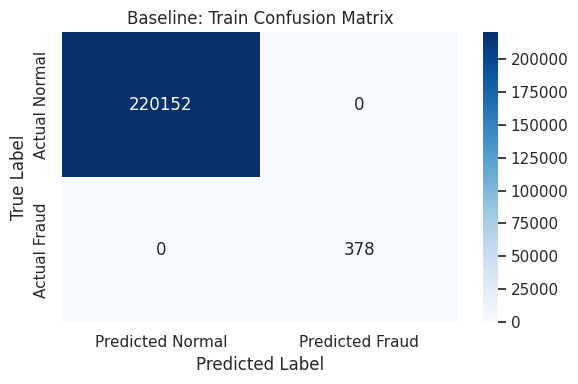

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Predicted Normal', 'Predicted Fraud'],
        yticklabels=['Actual Normal', 'Actual Fraud']
    )
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

print("=== Baseline — Train Set ===")
print(classification_report(y_train, y_base_train_pred))
plot_confusion_matrix(y_train, y_base_train_pred, title="Baseline: Train Confusion Matrix")

=== Baseline — Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.74      0.69      0.72        95

    accuracy                           1.00     55133
   macro avg       0.87      0.85      0.86     55133
weighted avg       1.00      1.00      1.00     55133



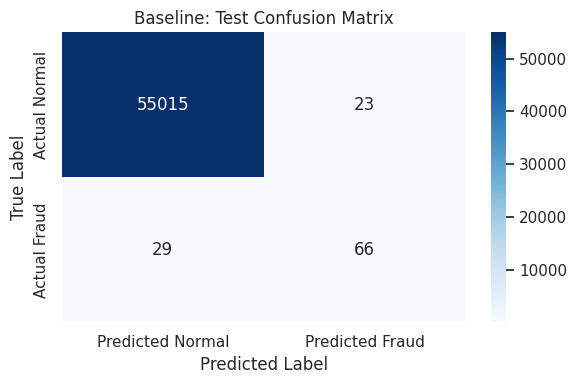

In [41]:
print("=== Baseline — Test Set ===")
print(classification_report(y_test, y_base_test_pred))
plot_confusion_matrix(y_test, y_base_test_pred, title="Baseline: Test Confusion Matrix")

In [42]:
y_train_proba = baseline_pipeline.predict_proba(X_train)[:, 1]
y_test_proba  = baseline_pipeline.predict_proba(X_test)[:, 1]

print(f"Baseline Train PR-AUC : {average_precision_score(y_train, y_train_proba):.4f}")
print(f"Baseline Test  PR-AUC : {average_precision_score(y_test, y_test_proba):.4f}")

Baseline Train PR-AUC : 1.0000
Baseline Test  PR-AUC : 0.5157


> **⚠️ Model Evaluation Note**
>
> The **99.9% accuracy** is a **deceptive metric** due to the extreme class imbalance (0.17% Fraud).  
> - **100% Train Accuracy** → clear **overfitting**.
> - **Test Recall = 0.69** → the model **missed 31% of actual fraud cases**.
>
> In a production environment, missing fraud is a **high financial risk**.  
> We must prioritize **Recall** and **F1-Score** over Accuracy.

**4.2 Cross-Validated Model Comparison (With Class Weighting)**

In [43]:
K_FOLDS = 5
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    "DecisionTree (balanced)": Pipeline([
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    "HistGradientBoosting (balanced)": Pipeline([
        ('model', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    "RandomForest (balanced)": Pipeline([
        ('model', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ]),
}

In [ ]:
cv_results = {}

for name, model_pipeline in candidate_models.items():
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring='average_precision')
    
    mean_score = float(scores.mean())
    cv_results[name] = mean_score
    clean_scores = [round(float(s), 4) for s in scores]
    
    print(f"Model: {name}")
    print(f"  Fold PR-AUC : {clean_scores}")
    print(f"  CV Mean     : {mean_score:.4f}")
    print("-" * 50)

best_model_name = max(cv_results, key=cv_results.get)
print(f"\nBest Model: {best_model_name} (PR-AUC = {cv_results[best_model_name]:.4f})")

Model: DecisionTree (balanced)
  Fold PR-AUC : [0.5732, 0.5655, 0.5522, 0.5858, 0.5285]
  CV Mean     : 0.5611
--------------------------------------------------
Model: HistGradientBoosting (balanced)
  Fold PR-AUC : [0.7154, 0.6692, 0.788, 0.8019, 0.6854]
  CV Mean     : 0.7320
--------------------------------------------------
Model: RandomForest (balanced)
  Fold PR-AUC : [0.8452, 0.8036, 0.8377, 0.8939, 0.791]
  CV Mean     : 0.8343
--------------------------------------------------

Best Model: RandomForest (balanced) (PR-AUC = 0.8343)


**4.3 Hyperparameter Tuning — RandomizedSearchCV on RandomForest**

In [45]:
rfc_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_grid = {
    'model__n_estimators'  : [200, 400],
    'model__max_depth'     : [15, 30],
    'model__min_samples_leaf': [1, 5, 15],
    'model__max_features'  : ['sqrt', 'log2', 0.01]
}

search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [46]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [15, 30], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 400]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [47]:
print("=" * 50)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 50)
print(f"Best CV PR-AUC : {search.best_score_:.4f}")
print("\nBest Parameters:")

for k, v in search.best_params_.items():
    print(f"  {k:<40} : {v}")

print("\nTop 5 Configurations:")
results_df = pd.DataFrame(search.cv_results_)
display(
    results_df[['params', 'mean_test_score', 'rank_test_score']]
    .sort_values(by='rank_test_score')
    .head(5)
)

HYPERPARAMETER TUNING RESULTS
Best CV PR-AUC : 0.8401

Best Parameters:
  model__n_estimators                      : 400
  model__min_samples_leaf                  : 5
  model__max_features                      : sqrt
  model__max_depth                         : 30

Top 5 Configurations:


,params,mean_test_score,rank_test_score
6,"{'model__n_estimators': 400, 'model__min_sampl...",0.840,1
5,"{'model__n_estimators': 400, 'model__min_sampl...",0.837,2
2,"{'model__n_estimators': 200, 'model__min_sampl...",0.835,3
8,"{'model__n_estimators': 200, 'model__min_sampl...",0.835,4
3,"{'model__n_estimators': 200, 'model__min_sampl...",0.835,5


**4.4 Train Final Best Model**

In [48]:
best_rfc = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators    = search.best_params_['model__n_estimators'],
        max_depth       = search.best_params_['model__max_depth'],
        min_samples_leaf= search.best_params_['model__min_samples_leaf'],
        max_features    = search.best_params_['model__max_features'],
        class_weight    = 'balanced_subsample',
        random_state    = RANDOM_STATE,
        n_jobs          = -1,
    ))
])

best_rfc.fit(X_train, y_train)
print("✅ Final model trained.")

✅ Final model trained.


---
## 5. Model Evaluation <a id='evaluation'></a>

In [49]:
y_train_pred = best_rfc.predict(X_train)
y_test_pred  = best_rfc.predict(X_test)

print(f"Best RFC Train Accuracy : {accuracy_score(y_train, y_train_pred) * 100:.2f}%")
print(f"Best RFC Test Accuracy  : {accuracy_score(y_test, y_test_pred) * 100:.2f}%")

Best RFC Train Accuracy : 99.99%
Best RFC Test Accuracy  : 99.94%


Final Model — Train Set: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    220152
           1       0.92      1.00      0.96       378

    accuracy                           1.00    220530
   macro avg       0.96      1.00      0.98    220530
weighted avg       1.00      1.00      1.00    220530



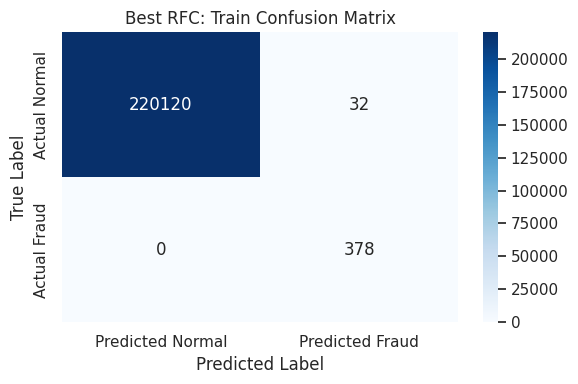

In [52]:
print("Final Model — Train Set: ")
print(classification_report(y_train, y_train_pred))
plot_confusion_matrix(y_train, y_train_pred, title="Best RFC: Train Confusion Matrix")

Final Model — Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.86      0.78      0.82        95

    accuracy                           1.00     55133
   macro avg       0.93      0.89      0.91     55133
weighted avg       1.00      1.00      1.00     55133



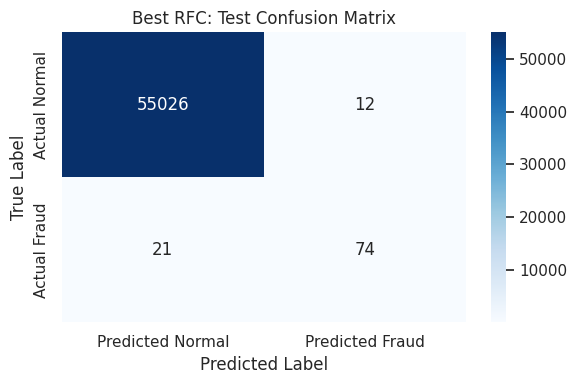

In [51]:
print("Final Model — Test Set:")
print(classification_report(y_test, y_test_pred))
plot_confusion_matrix(y_test, y_test_pred, title="Best RFC: Test Confusion Matrix")

In [33]:
train_proba = best_rfc.predict_proba(X_train)[:, 1]
test_proba  = best_rfc.predict_proba(X_test)[:, 1]

print(f"Best RFC Train PR-AUC : {average_precision_score(y_train, train_proba):.4f}")
print(f"Best RFC Test  PR-AUC : {average_precision_score(y_test, test_proba):.4f}")

Best RFC Train PR-AUC : 0.9860
Best RFC Test  PR-AUC : 0.8173


**5.2 Precision-Recall Curve & ROC Curve**

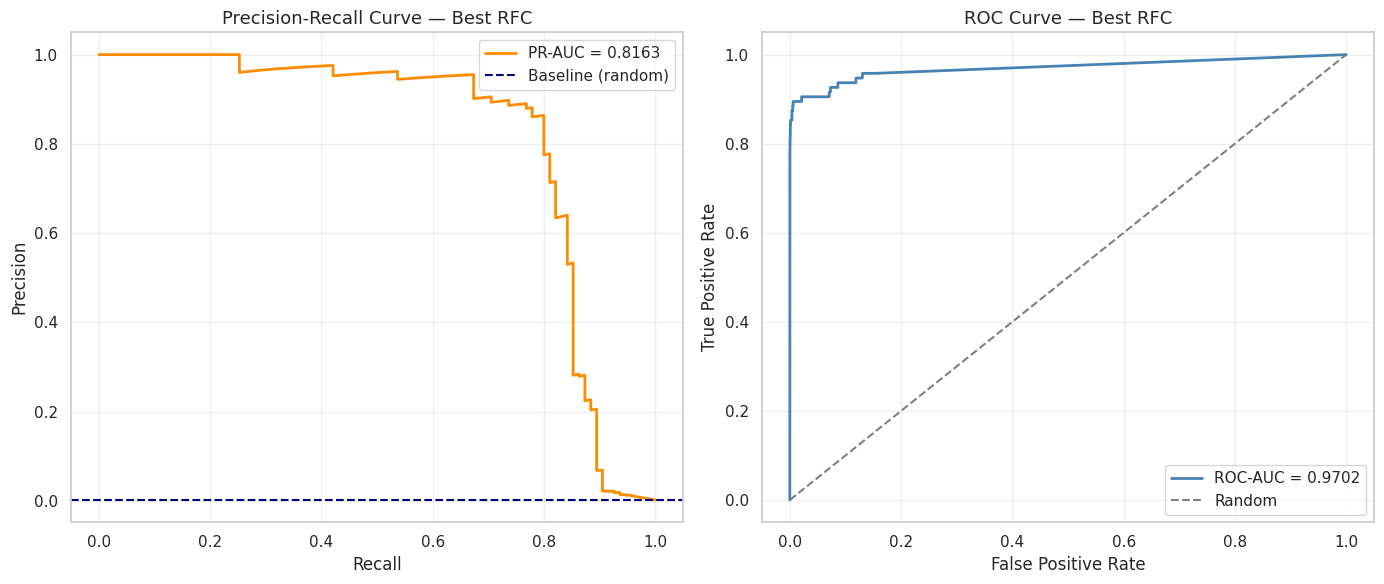

PR-AUC  : 0.8163
ROC-AUC : 0.9702


In [54]:
test_proba  = best_rfc.predict_proba(X_test)[:, 1]
train_proba = best_rfc.predict_proba(X_train)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)

fpr, tpr, _ = roc_curve(y_test, test_proba)
roc_auc = roc_auc_score(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(recall, precision, color='darkorange', linewidth=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[0].axhline(y=y_test.mean(), color='navy', linestyle='--', label='Baseline (random)')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve — Best RFC', fontsize=13)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC-AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve — Best RFC', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PR-AUC  : {pr_auc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")


**5.3 Feature Importance**

Top 15 Most Important Features:
   Feature  Importance
       V14       0.194
       V10       0.134
        V4       0.111
       V17       0.085
       V11       0.075
       V12       0.068
        V3       0.056
       V16       0.034
        V7       0.033
        V2       0.026
        V9       0.018
Amount_log       0.013
       V19       0.013
       V21       0.013
        V1       0.011


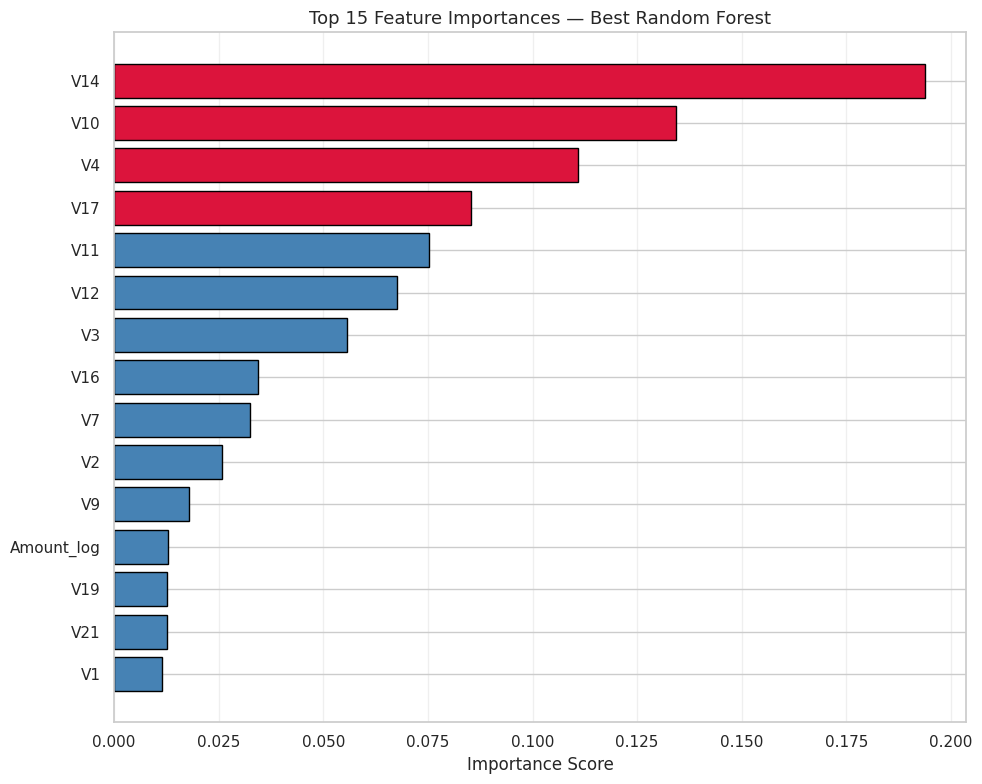

In [55]:
importances = best_rfc.named_steps['model'].feature_importances_
feat_names  = X_train.columns.tolist()

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features:")
print(feat_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top15 = feat_df.head(15)
colors = ['crimson' if imp > top15['Importance'].quantile(0.75) else 'steelblue'
          for imp in top15['Importance']]

ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1], edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances — Best Random Forest', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


**5.4 Model Saving**

In [ ]:
import joblib
import os

model_path = 'best_rfc_fraud_detector.joblib'
joblib.dump(best_rfc, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"✅ Model saved to: {model_path}")
print(f"   File size     : {size_kb:.1f} KB")

loaded_model  = joblib.load(model_path)
loaded_proba  = loaded_model.predict_proba(X_test)[:, 1]
loaded_pr_auc = average_precision_score(y_test, loaded_proba)
print(f"   Reload check  : PR-AUC = {loaded_pr_auc:.4f} ✅")

✅ Model saved to: best_rfc_fraud_detector.joblib
   File size     : 9704.3 KB
   Reload check  : PR-AUC = 0.8163 ✅
